# Synthetic Benchmark datasets


In [1]:
library(tidyverse)
library(ggplot2)

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# Read qc table from file
dt <- read_tsv("../../assembly/qc/qc_full.tsv", show_col_types = FALSE)
head(dt)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Number of mapped sequences,59,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of primary alignments,1429,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of secondary alignments,102,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of primary alignments with >65535 CIGAR operations,0,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of bases in mapped sequences,64585949,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of mapped bases,63548451,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA


Transform some of the values:

A transcript is considered to be single-copy (SC) if it has only one hit; otherwise it is considered multi-copy (MC). We do the same for the assembly and then compute the fraction of missing multi-copy gene as

    MMC = 1 - |{MCinASM} ∩ {MCinREF}| / |{MCinREF}|

In the ideal case of a perfect assembly, %MMC should be zero.

In [3]:
# Calculate MMC
dt_mmc <- dt %>%
  # First calculate MMC as before
  filter(metric %in% c("ref.dup_cnt", "asm.dup_cnt")) %>%
  pivot_wider(
    names_from = metric,
    values_from = value,
    values_fill = list(value = 0)
  ) %>%
  group_by(asm_name, haplotype, chromosome, source, asm_method) %>%
  summarise(
    ref_mc = sum(ref.dup_cnt),
    asm_mc = sum(asm.dup_cnt),
    value = 1 - asm_mc/ref_mc,
    .groups = 'drop'
  ) %>% 
  select( -ref_mc, -asm_mc) %>%
  mutate(metric = "MMC")

#head(dt_mmc)

In [4]:
# Calculate genome completeness
dt_completeness <- dt %>%
  filter(source == "asmgene") %>%
  group_by(asm_name, haplotype, chromosome, source, asm_method) %>%
  summarise(
    complete = sum(value[metric == "asm.full_sgl"]),
    total = sum(value[metric == "ref.full_sgl"]),
    value = (complete/total) * 100,
    .groups = 'drop'
  ) %>%
  select( -complete, -total) %>%
  mutate(metric = "genome_completeness")

#head(dt_completeness)

In [5]:
# add MMC and completeness to original table

dt <- bind_rows(dt, dt_completeness, dt_mmc)

In [6]:
# Extract deletion and insertion metrics
dt_indel_ranges <- dt %>%
  filter(str_detect(metric, "Number of (deletions|insertions) in")) %>%
  mutate(
    variant_type = if_else(str_detect(metric, "deletions"), "Deletion", "Insertion"),
    range = str_extract(metric, "\\[.*\\)"),
    range = str_remove_all(range, "[\\[\\)]"),
    range = str_replace(range, "inf", "10000")
  ) %>%
  separate(range, into = c("start", "end"), sep = ",") %>%
  mutate(
    start = as.numeric(start),
    end = as.numeric(end),
    mid_point = (start + end)/2
  )

#head(dt_indel_ranges)

In [7]:
print("All metrics:")

dt %>% pull(metric) %>% unique

# Remove  values from dataset
dt_reduced <- dt %>%
    filter(!str_detect(metric, "Number of")) %>%
    filter(!str_detect(metric, "asm.")) %>% filter(!str_detect(metric, "ref.")) %>%
    filter(!(source == "merqury" & str_detect(metric, "_kmers"))) %>%
    filter(!(source == "whatshap_compare" & str_detect(metric, "block"))) %>%
    filter(!(source == "whatshap_stats" & str_detect(metric, "_"))) %>%
    filter(!(source == "whatshap_stats" & str_detect(metric, "_"))) %>%
    filter(!(source == "t2t_motif")) %>%
    filter(!(source == "whatshap_compare" & metric %in% c("het_variants0", "only_snvs", 'all_assessed_pairs', 'all_switches'))) %>% 
    filter(!(source == "whatshap_stats" &  metric %in% c("covered_variants", "only_snvs"))) %>%
    filter(!(source == "asmstat" & str_detect(metric, "bp"))) %>%
    filter(!(source == "asmstat" & str_detect(metric, "l_cov")))

print("Essential metrics")
dt_reduced %>% pull(metric) %>% unique

[1] "All metrics:"


[1] "Number of mapped sequences"                               
 [2] "Number of primary alignments"                             
 [3] "Number of secondary alignments"                           
 [4] "Number of primary alignments with >65535 CIGAR operations"
 [5] "Number of bases in mapped sequences"                      
 [6] "Number of mapped bases"                                   
 [7] "Number of substitutions"                                  
 [8] "Number of insertions in [0,50)"                           
 [9] "Number of insertions in [50,100)"                         
[10] "Number of insertions in [100,300)"                        
[11] "Number of insertions in [300,400)"                        
[12] "Number of insertions in [400,1000)"                       
[13] "Number of insertions in [1000,inf)"                       
[14] "Number of deletions in [0,50)"                            
[15] "Number of deletions in [50,100)"                          
[16] "Number of deletions in [100,300)"                         
[17] "Number of deletions in [300,400)"                         
[18] "Number of deletions in [400,1000)"                        
[19] "Number of deletions in [1000,inf)"                        
[20] "Length"                                                   
[21] "l_cov"                                                    
[22] "Rcov"                                                     
[23] "Rdup"                                                     
[24] "Qcov"                                                     
[25] "NG75"                                                     
[26] "NG50"                                                     
[27] "NGA50"                                                    
[28] "AUNGA"                                                    
[29] "#breaks"                                                  
[30] "bp(10000,0)"                                              
[31] "bp(10000,10k)"                                            
[32] "ref.full_sgl"                                             
[33] "asm.full_sgl"                                             
[34] "ref.full_dup"                                             
[35] "asm.full_dup"                                             
[36] "ref.frag"                                                 
[37] "asm.frag"                                                 
[38] "ref.part50+"                                              
[39] "asm.part50+"                                              
[40] "ref.part10+"                                              
[41] "asm.part10+"                                              
[42] "ref.part10-"                                              
[43] "asm.part10-"                                              
[44] "ref.dup_cnt"                                              
[45] "asm.dup_cnt"                                              
[46] "ref.dup_sum"                                              
[47] "asm.dup_sum"                                              
[48] "variants"                                                 
[49] "phased"                                                   
[50] "unphased"                                                 
[51] "singletons"                                               
[52] "blocks"                                                   
[53] "variant_per_block_median"                                 
[54] "variant_per_block_avg"                                    
[55] "variant_per_block_min"                                    
[56] "variant_per_block_max"                                    
[57] "variant_per_block_sum"                                    
[58] "bp_per_block_median"                                      
[59] "bp_per_block_avg"                                         
[60] "bp_per_block_min"                                         
[61] "bp_per_block_max"                                         
[62] "bp_per_block_sum"             

[1] "Essential metrics"


[1] "Length"              "Rcov"                "Rdup"               
 [4] "Qcov"                "NG75"                "NG50"               
 [7] "NGA50"               "AUNGA"               "#breaks"            
[10] "variants"            "phased"              "unphased"           
[13] "singletons"          "blocks"              "covered_variants"   
[16] "all_switch_rate"     "all_switchflip_rate" "qv"                 
[19] "error_rate"          "n_T2T"               "n_y_chrom"          
[22] "genome_completeness" "MMC"

In [8]:
# Rename metrics to better names used in plotting
dt_reduced <- dt_reduced %>%
    mutate(
        metric = case_when(
            metric == "NG50" ~ "NG50",
            metric == "n_T2T" ~ "Number of T2T chromosomes",
            metric == "qv" ~ "Quality Value",
            metric == "error_rate" ~ "Error Rate",
            metric == "all_switch_rate" ~ "Switch Rate (%)",
            metric == "#breaks" ~ "Number of Breaks in Assembly",
            metric == "MMC" ~ "Missing Multi-Copy Genes (%)",
            metric == "Length" ~ "Assembly Length",
            metric == "Rcov" ~ "% of Ref covered by Assembly",
            metric == "Rdup" ~ "% of Ref duplicated in Assembly",
            metric == "Qcov" ~ "% of Assembly covered by Ref",
            metric == "NG75" ~ "NG75",
            metric == "NGA50" ~ "NGA50",
            metric == "AUNGA" ~ "Average Ungapped Alignment length",
            metric == "variants" ~ "Variants",
            metric == "phased" ~ "Variants Phased",
            metric == "unphased" ~ "Variants Unphased",
            metric == "blocks" ~ "Phase Blocks",
            metric == "covered_variants" ~ "Covered Variants",
            metric == "all_switchflip_rate" ~ "Switch Flip Rate (%)",
            metric == "n_y_chrom" ~ "Number of Y Chromosomes",
            metric == "genome_completeness" ~ "Genome Completeness",
            TRUE ~ metric
            
        )
    )

In [9]:
dt_reduced %>% pull(metric) %>% unique

[1] "Assembly Length"                   "% of Ref covered by Assembly"     
 [3] "% of Ref duplicated in Assembly"   "% of Assembly covered by Ref"     
 [5] "NG75"                              "NG50"                             
 [7] "NGA50"                             "Average Ungapped Alignment length"
 [9] "Number of Breaks in Assembly"      "Variants"                         
[11] "Variants Phased"                   "Variants Unphased"                
[13] "singletons"                        "Phase Blocks"                     
[15] "Covered Variants"                  "Switch Rate (%)"                  
[17] "Switch Flip Rate (%)"              "Quality Value"                    
[19] "Error Rate"                        "Number of T2T chromosomes"        
[21] "Number of Y Chromosomes"           "Genome Completeness"              
[23] "Missing Multi-Copy Genes (%)"

In [10]:
# Create new column seqtype with either duplex, herro or combined
dt_reduced_typed <- dt_reduced %>%
  filter(str_detect(asm_name, "published")) %>%
  filter(!str_detect(asm_name, "nopolish")) %>%
  filter(asm_method=="phased_verkko") %>%
  mutate(
    seq_type = case_when(
      str_detect(asm_name, "duplex") ~ "duplex",
      str_detect(asm_name, "herro") ~ "herro",
      str_detect(asm_name, "combined") ~ "combined",
      TRUE ~ NA_character_
    ),
    asm_name = str_remove(asm_name, "duplex|herro") %>%
        str_replace("__", "_") %>%
        str_remove_all("_$")
  )

In [11]:
# Remove chromosomes from whatshap stats
dt_reduced_typed_nochr <- dt_reduced_typed %>% 
    filter(!(str_detect(source, "whatshap_stats") & chromosome != "ALL")) %>%
    group_by(seq_type, metric, haplotype,source, asm_name) %>%
    reframe(
        value = case_when(
            str_detect(metric, "Rate|rate") ~ mean(value, na.rm = TRUE),
            metric == "Variants" ~ sum(value, na.rm = TRUE),
            TRUE ~ sum(value, na.rm = TRUE)
        ),
        .groups = 'drop'
    )

### Compare duplex to herro

We will both compare the subsampled chr19 datasets and the full

#### Full assemblies

In [12]:
dt_HvD_full <- dt_reduced_typed_nochr %>% filter(asm_name == "published")

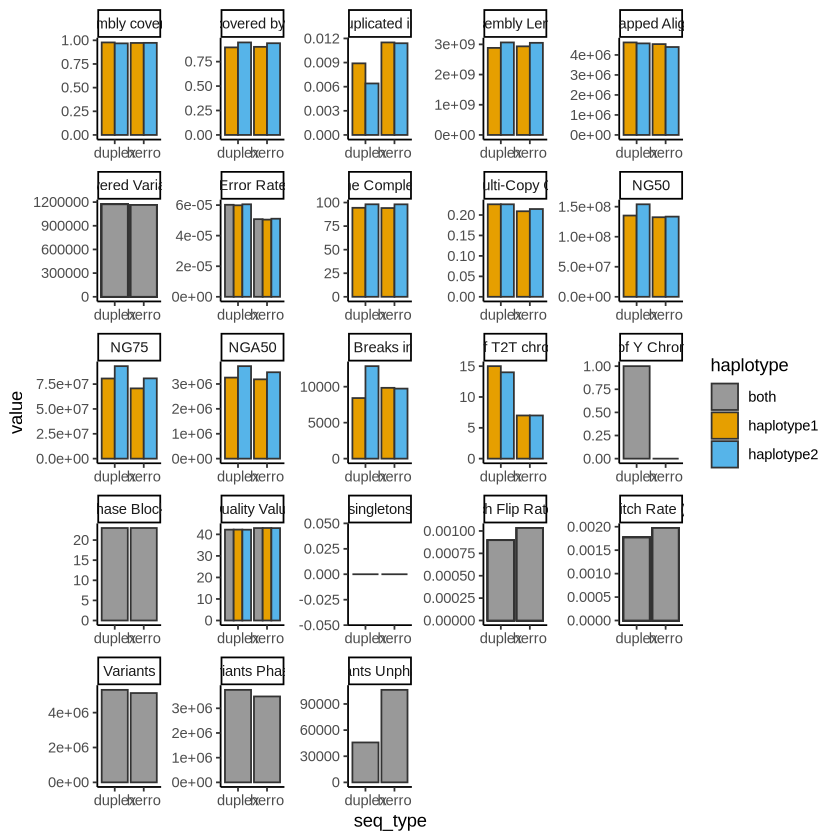

In [13]:
dt_HvD_full  %>% 
    ggplot(aes(x = seq_type, y = value, fill = haplotype)) + 
        facet_wrap(~metric, scales = "free") + 
        geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442")) +
        theme_classic()

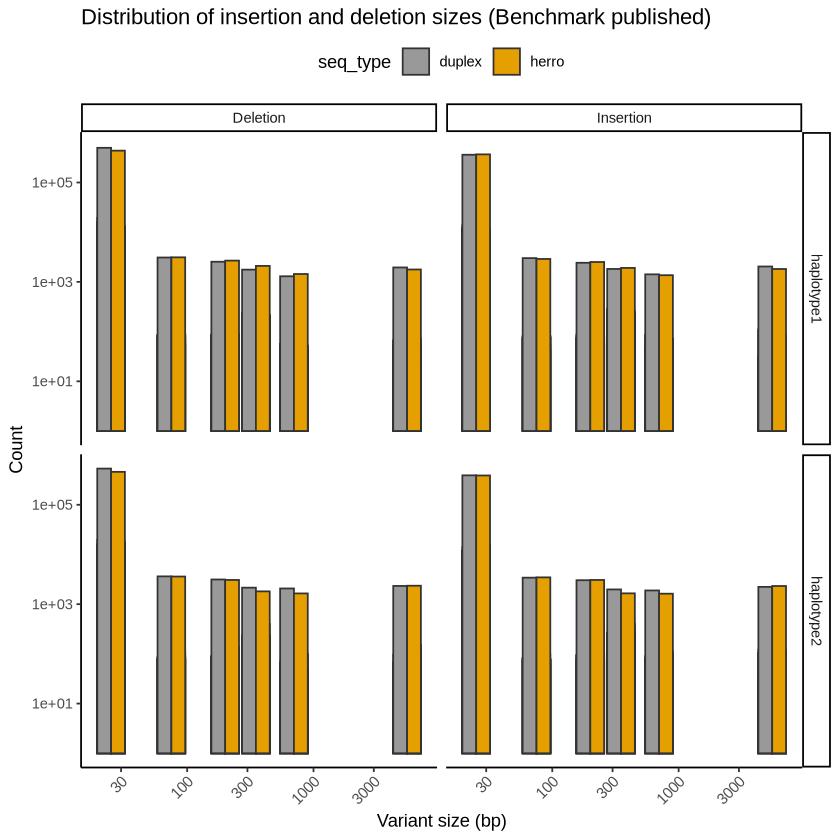

In [14]:
# Create faceted indel plot
# Filter to published herro vs duplex comparison only
dt_herro_vs_duplex_indel <- dt_indel_ranges %>%
  filter(str_detect(asm_name, "published")) %>%
  filter(!str_detect(asm_name, "nopolish")) %>%
  filter(asm_method=="phased_verkko") %>%
  mutate(
    seq_type = case_when(
      str_detect(asm_name, "duplex") ~ "duplex",
      str_detect(asm_name, "herro") ~ "herro",
      TRUE ~ NA_character_
    ),
    asm_name = str_remove(asm_name, "duplex|herro") %>%
        str_replace("__", "_") %>%
        str_remove_all("_$")
  ) %>%
  filter(seq_type %in% c("duplex", "herro"))

ggplot(dt_herro_vs_duplex_indel, aes(x = mid_point, y = value, fill = seq_type)) +
  geom_bar(stat = "identity", position = "dodge", col = "grey20") +
  facet_grid(haplotype ~ variant_type) +
  scale_x_log10() +
  scale_fill_manual(values = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442")) +
  labs(
    x = "Variant size (bp)",
    y = "Count",
    title = "Distribution of insertion and deletion sizes (Benchmark published)"
  ) +
  scale_y_log10() +
  theme_classic() +
  theme(
    legend.position = "top",
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

In [15]:
dt_HvD_full %>%
  filter(asm_name == "published") %>%
  group_by(seq_type, metric, haplotype, source) %>%
  summarise(value = sum(value, na.rm = TRUE), .groups = 'drop') %>%
  mutate(
    formatted_value = case_when(

      metric %in% c("Error Rate") ~ paste0(round(value * 100, 3), "%"),
      TRUE ~ as.character(round(value, 2))
    )
  ) %>%
  select(-value) %>%  # Remove original value column
  pivot_wider(
    names_from = seq_type, 
    values_from = formatted_value
  ) %>%
  arrange(source, metric, haplotype) %>%
  knitr::kable()



|metric                            |haplotype  |source            |duplex     |herro      |
|:---------------------------------|:----------|:-----------------|:----------|:----------|
|Genome Completeness               |haplotype1 |asmgene           |94.41      |94.16      |
|Genome Completeness               |haplotype2 |asmgene           |98.14      |98.09      |
|Missing Multi-Copy Genes (%)      |haplotype1 |asmgene           |0.23       |0.21       |
|Missing Multi-Copy Genes (%)      |haplotype2 |asmgene           |0.23       |0.21       |
|% of Assembly covered by Ref      |haplotype1 |asmstat           |0.98       |0.97       |
|% of Assembly covered by Ref      |haplotype2 |asmstat           |0.97       |0.97       |
|% of Ref covered by Assembly      |haplotype1 |asmstat           |0.9        |0.9        |
|% of Ref covered by Assembly      |haplotype2 |asmstat           |0.95       |0.94       |
|% of Ref duplicated in Assembly   |haplotype1 |asmstat           |0.01       

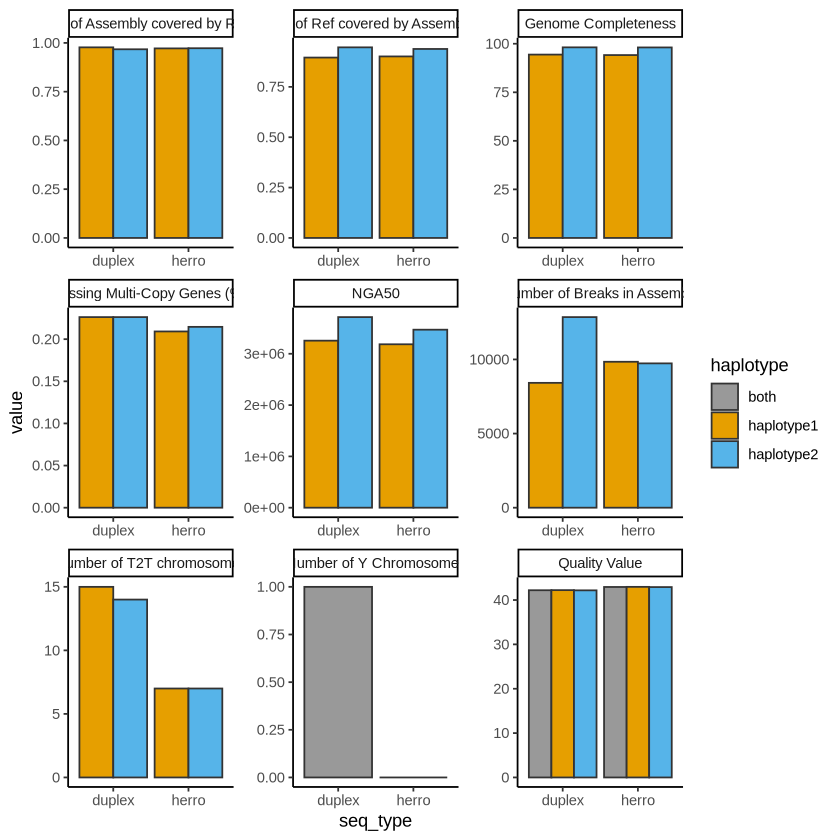

In [16]:
dt_HvD_full  %>% 
    filter(metric %in% c(
        "Genome Completeness",
         "Missing Multi-Copy Genes (%)",
         "% of Assembly covered by Ref",
         "% of Ref covered by Assembly",
         "NGA50",
         "Number of Breaks in Assembly",
         "Switch Error", "Quality Value", 
         "Number of T2T chromosomes",
         "Number of Y Chromosomes"
         )) %>%
    ggplot(aes(x = seq_type, y = value, fill = haplotype)) +
        facet_wrap(~metric, scales = "free") + 
        geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442")) +
        theme_classic()

### Compare chr19 assemblies

In [1]:
dt_reduced %>% 
    filter(str_detect(asm_name, 'chr19')) %>%
    pull(asm_name) %>% unique %>% print

ERROR: Error in dt_reduced %>% filter(str_detect(asm_name, "chr19")) %>% pull(asm_name) %>% : could not find function "%>%"


In [ ]:
dt_reduced %>%
    filter(str_detect(asm_name, 'chr19')) %>%
    mutate(type = case_when(
        str_detect(asm_name, "duplex") ~ "duplex",
        str_detect(asm_name, "herro") ~ "herro",
        str_detect(asm_name, "combined") ~ "combined",
        TRUE ~ "other"
    ))
